In [ ]:
import pandas as pd
import datetime
import requests
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# - CoinGecko — 무료로 비트코인 과거 가격 데이터를 CSV 또는 API로 제공.
# - CryptoDataDownload.com — 암호화폐 과거 시세(일봉, 시간봉 등) CSV를 무료로 제공.
# - CoinMarketCap 의 Historical Data 페이지 — BTC의 과거 종가/시가/거래량 등을 확인하고 CSV로 다운로드 가능.
# → 위 출처 중 하나에서 CSV로 다운로드하거나, API를 통해 자동으로 데이터를 받아올 수 있음.

In [ ]:
# 유의사항 / 한계

# 암호화폐 시장은 24시간, 7일 연속 운영되므로, 시계열 분석 시 타임존 / 시간 정확도에 주의해야 함
# 일부 API/사이트는 분봉 데이터 제공하지만, 무료 버전은 기간/횟수 제한이 있을 수 있음
# 과거 데이터의 공백(거래량 0, 일부 결측치 등)이 있을 수 있으므로 결측치 처리 필요
# 단순 과거 값만으로 미래 예측은 불확실성이 크므로, 분석 목적과 가정을 명확히 할 것

In [ ]:
# 1) CoinGecko API를 사용해 최근 5년치 일봉 가격 가져오기
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "usd",
    "days": 365,  # 약 1년치 데이터
    "interval": "daily"
}

In [ ]:
resp = requests.get(url, params=params) #json형태의 string이 http의 body에 있음.
data = resp.json() #json---> dict

In [ ]:
type(data)

dict

In [ ]:
data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [ ]:
# data

# {'prices': [[1732752000000, 95981.18057210564],
#   [1732838400000, 95661.59595817851],
#   [1732924800000, 97453.2473451042],
#   [1733011200000, 96513.14234698225],
#   [1733097600000, 97311.70719084324],
#   [1733184000000, 95833.1362300365],

In [ ]:
df = pd.DataFrame(data["prices"], columns=["timestamp", "price_usd"])
df.head(2)

,timestamp,price_usd
0,1732752000000,95981.180572
1,1732838400000,95661.595958


In [ ]:
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df.head(2)

,timestamp,price_usd,date
0,1732752000000,95981.180572,2024-11-28
1,1732838400000,95661.595958,2024-11-29


In [ ]:
df.tail(2)

,timestamp,price_usd,date
364,1764201600000,90474.226780,2025-11-27 00:00:00
365,1764237020000,91697.279626,2025-11-27 09:50:20


In [ ]:
#마지막 행 삭제
df = df.drop(df.index[-1])
df.tail(2)

,timestamp,price_usd,date
363,1764115200000,87310.33160,2025-11-26
364,1764201600000,90474.22678,2025-11-27


In [ ]:
df = df.drop(columns="timestamp")
df.head(2)

,price_usd,date
0,95981.180572,2024-11-28
1,95661.595958,2024-11-29


In [ ]:
print(df.head(2))
print(df.tail(2))
print("데이터 개수:", len(df))

      price_usd       date
0  95981.180572 2024-11-28
1  95661.595958 2024-11-29
       price_usd       date
363  87310.33160 2025-11-26
364  90474.22678 2025-11-27
데이터 개수: 365


In [ ]:
df.head(2)

,price_usd,date
0,95981.180572,2024-11-28
1,95661.595958,2024-11-29


In [ ]:
df.set_index("date", inplace=True)
df.head(2)

,price_usd
date,
2024-11-28,95981.180572
2024-11-29,95661.595958


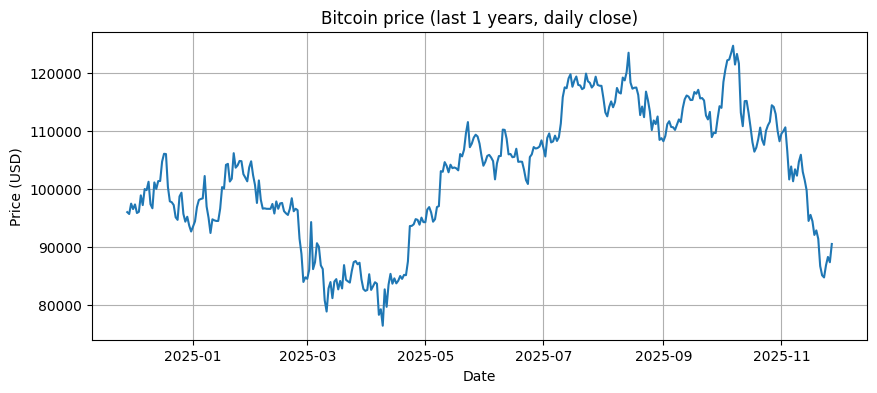

In [ ]:
# 2) 간단한 시계열 시각화
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["price_usd"])
plt.title("Bitcoin price (last 1 years, daily close)")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [ ]:
btc = df.copy() #깊은 복사

In [ ]:
# 아리마 모델로 학습시켜보시고, 예측해보세요.
# 앞으로 30일을 예측해보세요.

In [ ]:
# 1. arima객체 생성, series를 학습할 예정, (1,1,1)
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(btc, order=(1,1,1))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# 2. 학습시킴
fit = model.fit()

In [ ]:
# 3. 앞으로 30일치 예측
forecast_res = fit.get_forecast(steps=30)

In [ ]:
# 4. 전체 예측한 결과 conf_int에 넣음.
conf_int = forecast_res.conf_int()

In [ ]:
conf_int['yhat'] = (conf_int['upper price_usd']+conf_int['lower price_usd'])/2

In [ ]:
conf_int.tail(2)

,lower price_usd,upper price_usd,yhat
2025-12-26,67570.155605,113306.252014,90438.20381
2025-12-27,67179.393252,113697.014369,90438.20381


In [ ]:
conf_int.index

DatetimeIndex(['2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01',
               '2025-12-02', '2025-12-03', '2025-12-04', '2025-12-05',
               '2025-12-06', '2025-12-07', '2025-12-08', '2025-12-09',
               '2025-12-10', '2025-12-11', '2025-12-12', '2025-12-13',
               '2025-12-14', '2025-12-15', '2025-12-16', '2025-12-17',
               '2025-12-18', '2025-12-19', '2025-12-20', '2025-12-21',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27'],
              dtype='datetime64[ns]', freq='D')

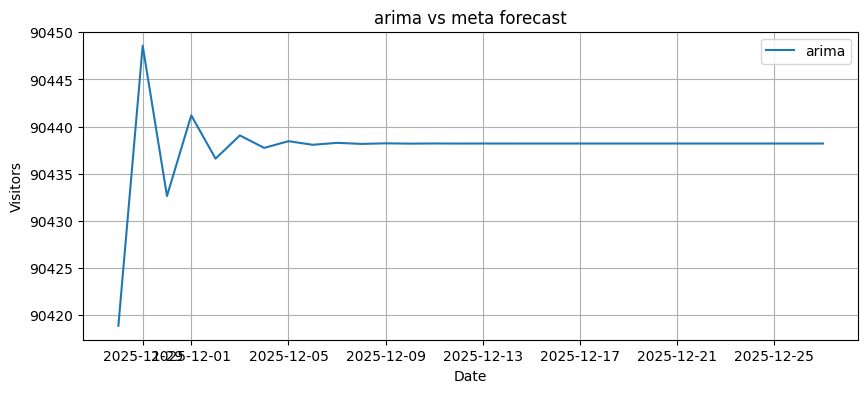

In [ ]:
# arima
plt.figure(figsize=(10,4))
plt.plot(conf_int.index, conf_int['yhat'], label="arima")
plt.title("arima vs meta forecast")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend() #범례
plt.grid(True)
plt.show()

In [ ]:
# 메타모델로 학습시켜보시고, 예측해보세요.
# 앞으로 30일을 예측해보세요.

# 메타모델은 인덱스를 날짜로 설정하지 않고, ds컬럼으로 설정해야함.
# 값은 y컬럼에 들어가 있어야함.